# Dragon Fruit Plant Image Optimizer Study — VGG19 Implementation

This notebook implements the Dragon Fruit binary classification experiment with VGG19 active.

Project setup retained:
- Binary classification: `comdoença` / `Comdoenca` = with disease, `semdoença` / `Endoenca` = without disease
- Input size: 256 × 256
- Batch size: 32
- Epochs: 50
- Dense head: 256 → 128 → 64
- Dropout: 0.6 → 0.4 → 0.3
- Optimizers: Adam, Adagrad, Adamax, Adadelta, SGD, RMSprop
- Learning rates: 0.0001, 0.00001, 0.000001

VGG19 is the only active transfer learning model in `MODELS_TO_RUN`. The other pretrained models are left in the builder but commented out in the experiment list so they can be enabled later if the whole 72-simulation requirement is needed.


In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import unicodedata

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG19, EfficientNetB3, ResNet50, DenseNet121
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
DATASET_DIR = Path("Dataset")
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 50

OUTPUT_DIR = Path("outputs_vgg19")
PLOTS_DIR = OUTPUT_DIR / "plots"
REPORTS_DIR = OUTPUT_DIR / "reports"
CONFUSION_DIR = OUTPUT_DIR / "confusion_matrices"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_DIR.mkdir(parents=True, exist_ok=True)

for required_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not required_dir.exists():
        raise FileNotFoundError(f"Missing directory: {required_dir}")


In [3]:
for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))


Dataset\test\comdoença\cd (1).jpg
Dataset\test\comdoença\cd (10).jpg
Dataset\test\comdoença\cd (11).jpg
Dataset\test\comdoença\cd (12).jpg
Dataset\test\comdoença\cd (13).jpg
Dataset\test\semdoença\sd (1).jpg
Dataset\test\semdoença\sd (10).jpg
Dataset\test\semdoença\sd (11).jpg
Dataset\test\semdoença\sd (12).jpg
Dataset\test\semdoença\sd (13).jpg
Dataset\train\comdoença\cd (144).jpg
Dataset\train\comdoença\cd (145).jpg
Dataset\train\comdoença\cd (146).jpg
Dataset\train\comdoença\cd (147).jpg
Dataset\train\comdoença\cd (148).jpg
Dataset\train\semdoença\sd (144).jpg
Dataset\train\semdoença\sd (145).jpg
Dataset\train\semdoença\sd (146).jpg
Dataset\train\semdoença\sd (147).jpg
Dataset\train\semdoença\sd (148).jpg
Dataset\validation\comdoença\cd (100).jpg
Dataset\validation\comdoença\cd (101).jpg
Dataset\validation\comdoença\cd (102).jpg
Dataset\validation\comdoença\cd (103).jpg
Dataset\validation\comdoença\cd (104).jpg
Dataset\validation\semdoença\sd (100).jpg
Dataset\validation\semdoença\s

## Data Generators

Training uses augmentation and normalization. Validation and test use normalization only. Test is set to `shuffle=False` so predictions line up with `test.classes`.


In [4]:
image_generatorFullAugment = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    shear_range=0.3,
    zoom_range=0.30,
    horizontal_flip=True,
    samplewise_center=True,
    samplewise_std_normalization=True,
)

image_generatorNoAugment = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True,
)


In [5]:
train = image_generatorFullAugment.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
)

validation = image_generatorNoAugment.flow_from_directory(
    VAL_DIR,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=False,
)

test = image_generatorNoAugment.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=False,
)

print("Class indices:", train.class_indices)


Found 315 images belonging to 2 classes.
Found 105 images belonging to 2 classes.
Found 180 images belonging to 2 classes.
Class indices: {'comdoença': 0, 'semdoença': 1}


## Experiment Settings

For your assigned VGG19 task, only VGG19 is active. To run the complete project requirement later, uncomment the other models in `MODELS_TO_RUN`.


In [6]:
LEARNING_RATES = [0.0001, 0.00001, 0.000001]
OPTIMIZERS = ["adam", "adagrad", "adamax", "adadelta", "sgd", "rmsprop"]

MODELS_TO_RUN = [
    "vgg19",
    # "efficientnetb3",
    # "resnet50",
    # "densenet121",
]

POSITIVE_CLASS_NAMES = [
    "Comdoenca",
    "comdoenca",
    "comdoença",
    "With Disease",
    "with disease",
]


def normalize_class_name(name):
    name = name.lower().strip()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(char for char in name if not unicodedata.combining(char))
    return name


def get_positive_class_index(generator):
    normalized_positive_names = [
        normalize_class_name(name) for name in POSITIVE_CLASS_NAMES
    ]

    for class_name, class_index in generator.class_indices.items():
        if normalize_class_name(class_name) in normalized_positive_names:
            return class_index

    raise ValueError(
        f"Positive disease class was not found. Available classes: {generator.class_indices}"
    )


def get_disease_scores(raw_prob_class_1, positive_class_index):
    if positive_class_index == 1:
        return raw_prob_class_1

    return 1.0 - raw_prob_class_1


In [7]:
def get_optimizer(optimizer_name, lr):
    optimizer_name = optimizer_name.lower()

    optimizers = {
        "adam": tf.keras.optimizers.Adam,
        "adagrad": tf.keras.optimizers.Adagrad,
        "adamax": tf.keras.optimizers.Adamax,
        "adadelta": tf.keras.optimizers.Adadelta,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop,
    }

    if optimizer_name not in optimizers:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizers[optimizer_name](learning_rate=lr)


def get_base_model(model_name):
    model_name = model_name.lower()

    if model_name == "vgg19":
        return VGG19(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "efficientnetb3":
        return EfficientNetB3(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "resnet50":
        return ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "densenet121":
        return DenseNet121(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    raise ValueError(f"Unsupported model: {model_name}")


def build_model(model_name, lr, optimizer_name):
    tf.keras.backend.clear_session()

    base_model = get_base_model(model_name)
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.6),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=get_optimizer(optimizer_name, lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model


In [8]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0


def evaluate_predictions(test_generator, raw_prob_class_1, model_name, optimizer_name, lr):
    positive_class_index = get_positive_class_index(test_generator)

    y_true = (test_generator.classes == positive_class_index).astype(int)
    y_score = get_disease_scores(raw_prob_class_1, positive_class_index)
    y_pred = (y_score >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "model": model_name,
        "optimizer": optimizer_name,
        "learning_rate": lr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": safe_divide(tn, tn + fp),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Without Disease", "With Disease"],
        output_dict=True,
        zero_division=0,
    )

    return metrics, pd.DataFrame(report).transpose(), y_true, y_score, y_pred


In [9]:
def plot_training_history(history, run_name):
    history_dict = history.history

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(history_dict.get("loss", []), label="Loss")
    axes[0, 0].plot(history_dict.get("val_loss", []), label="Val_Loss")
    axes[0, 0].set_title("Loss Evolution")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(history_dict.get("accuracy", []), label="Accuracy")
    axes[0, 1].plot(history_dict.get("val_accuracy", []), label="Val_Accuracy")
    axes[0, 1].set_title("Accuracy Evolution")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()

    axes[1, 0].plot(history_dict.get("auc", []), label="AUC")
    axes[1, 0].plot(history_dict.get("val_auc", []), label="Val_AUC")
    axes[1, 0].set_title("AUC Evolution")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("AUC")
    axes[1, 0].legend()

    axes[1, 1].axis("off")

    fig.suptitle(run_name)
    fig.tight_layout()

    path = PLOTS_DIR / f"{run_name}_history.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path


def plot_roc_curve(y_true, y_score, run_name):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_value = roc_auc_score(y_true, y_score)

    fig = plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"ROC Curve — {run_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()

    path = PLOTS_DIR / f"{run_name}_roc.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path


In [19]:
def run_experiment(model_name, optimizer_name, lr):
    run_name = f"{model_name}_{optimizer_name}_lr_{lr:g}".replace(".", "p")
    print()
    print(f"Running: {run_name}")

    model = build_model(model_name, lr, optimizer_name)

    history = model.fit(
        train,
        epochs=EPOCHS,
        validation_data=validation,
        verbose=1,
    )

    test.reset()
    raw_prob_class_1 = model.predict(test, verbose=0).ravel()

    metrics, report_df, y_true, y_score, y_pred = evaluate_predictions(
        test,
        raw_prob_class_1,
        model_name,
        optimizer_name,
        lr,
    )

    history_plot_path = plot_training_history(history, run_name)
    roc_plot_path = plot_roc_curve(y_true, y_score, run_name)

    report_path = REPORTS_DIR / f"{run_name}_classification_report.csv"
    report_df.to_csv(report_path)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_df = pd.DataFrame(
        cm,
        index=["Actual Without Disease", "Actual With Disease"],
        columns=["Predicted Without Disease", "Predicted With Disease"],
    )

    confusion_path = CONFUSION_DIR / f"{run_name}_confusion_matrix.csv"
    confusion_df.to_csv(confusion_path)

    metrics["history_plot"] = str(history_plot_path)
    metrics["roc_plot"] = str(roc_plot_path)
    metrics["classification_report"] = str(report_path)
    metrics["confusion_matrix"] = str(confusion_path)

    print("Confusion matrix using With Disease as positive class:")
    display(confusion_df)
    display(pd.DataFrame([metrics]))
    display(report_df)

    return metrics

Skipping completed run: vgg19_adam_lr_0p0001
Skipping completed run: vgg19_adam_lr_1e-05
Skipping completed run: vgg19_adam_lr_1e-06

Running: vgg19_adagrad_lr_0p0001

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.5048 - auc: 0.5195 - loss: 0.9165 - precision: 0.5061 - recall: 0.5253 - val_accuracy: 0.4952 - val_auc: 0.5201 - val_loss: 0.7177 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.4222 - auc: 0.4331 - loss: 1.0227 - precision: 0.4221 - recall: 0.4114 - val_accuracy: 0.4952 - val_auc: 0.5281 - val_loss: 0.6969 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.4952 - auc: 0.4902 - loss: 0.9977 - precision: 0.4967 - recall: 0.4747 - val_accuracy: 0.5333 - val_auc: 0.5214 - val_loss: 0.6926 - val_precision: 0.5283 - val_recall: 0.5385
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4857 - auc: 0.4734 - loss: 0.9866 - precision: 0

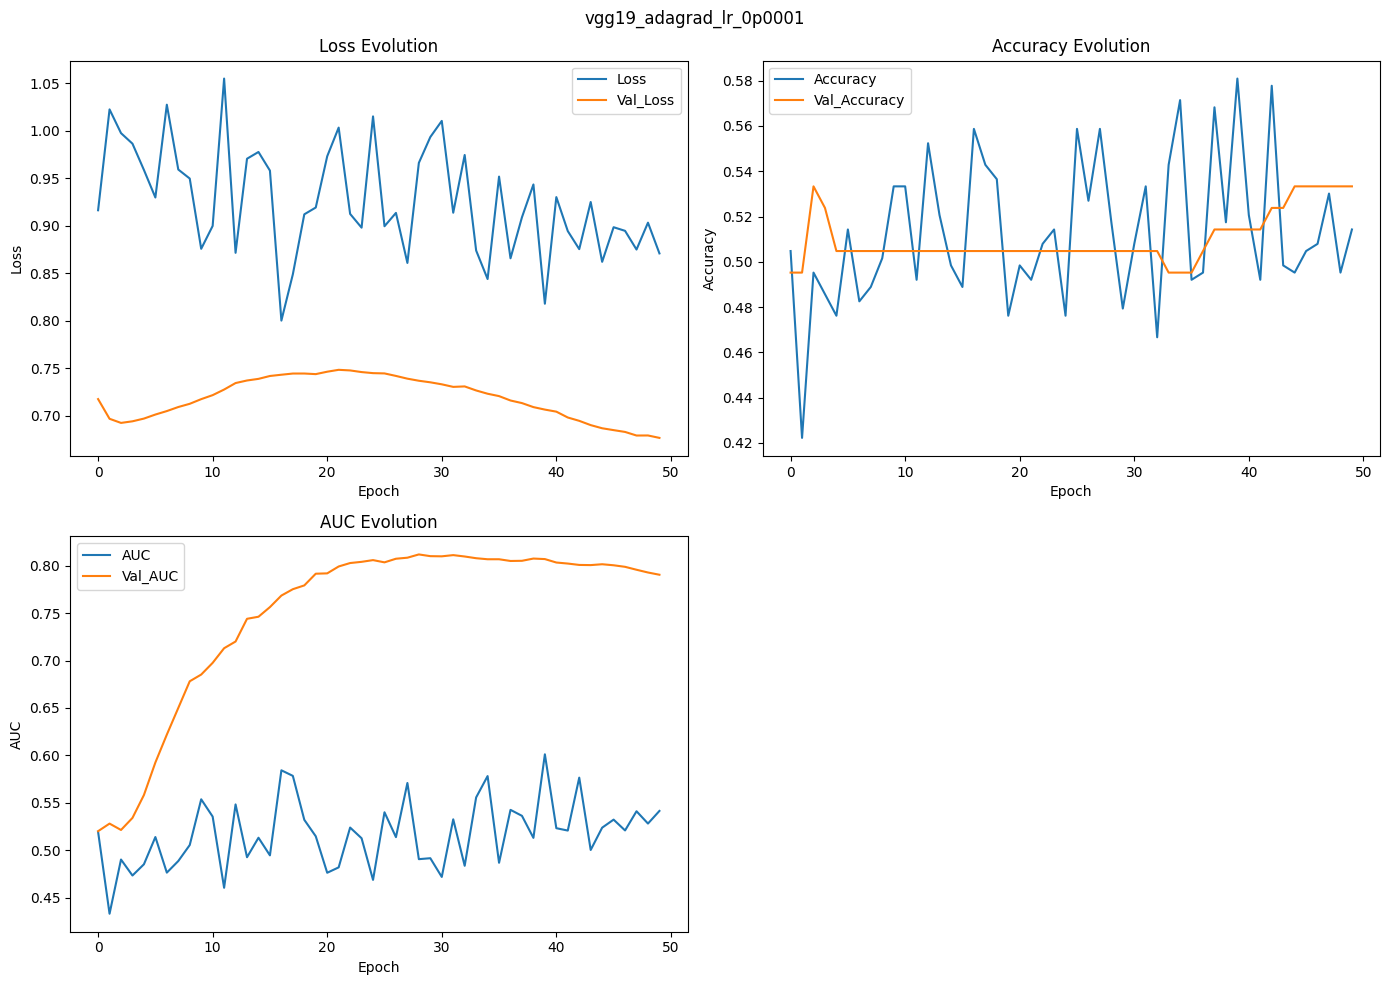

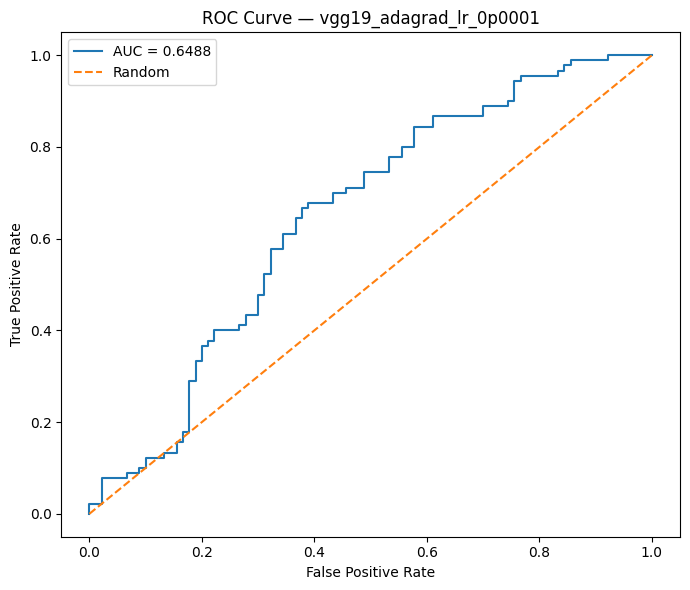

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,8,82
Actual With Disease,1,89


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adagrad,0.0001,0.538889,0.520468,0.988889,0.088889,0.681992,0.648765,8,82,1,89,outputs_vgg19\plots\vgg19_adagrad_lr_0p0001_hi...,outputs_vgg19\plots\vgg19_adagrad_lr_0p0001_ro...,outputs_vgg19\reports\vgg19_adagrad_lr_0p0001_...,outputs_vgg19\confusion_matrices\vgg19_adagrad...


,precision,recall,f1-score,support
Without Disease,0.888889,0.088889,0.161616,90.000000
With Disease,0.520468,0.988889,0.681992,90.000000
accuracy,0.538889,0.538889,0.538889,0.538889
macro avg,0.704678,0.538889,0.421804,180.000000
weighted avg,0.704678,0.538889,0.421804,180.000000



Running: vgg19_adagrad_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.5683 - auc: 0.5743 - loss: 0.8611 - precision: 0.5671 - recall: 0.5886 - val_accuracy: 0.5048 - val_auc: 0.3217 - val_loss: 0.7313 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.5270 - auc: 0.5081 - loss: 0.9977 - precision: 0.5263 - recall: 0.5696 - val_accuracy: 0.5048 - val_auc: 0.3249 - val_loss: 0.7235 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.5048 - auc: 0.5154 - loss: 0.9499 - precision: 0.5068 - recall: 0.4684 - val_accuracy: 0.4762 - val_auc: 0.3110 - val_loss: 0.7196 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4698 - auc: 0.4647 - loss: 1.0394 - precision: 0.4710 - recall: 0.4620 - val_accuracy: 0.4095 - val_auc: 0.3050 - val_loss: 0.7179 - val_precision: 0.2917 - va

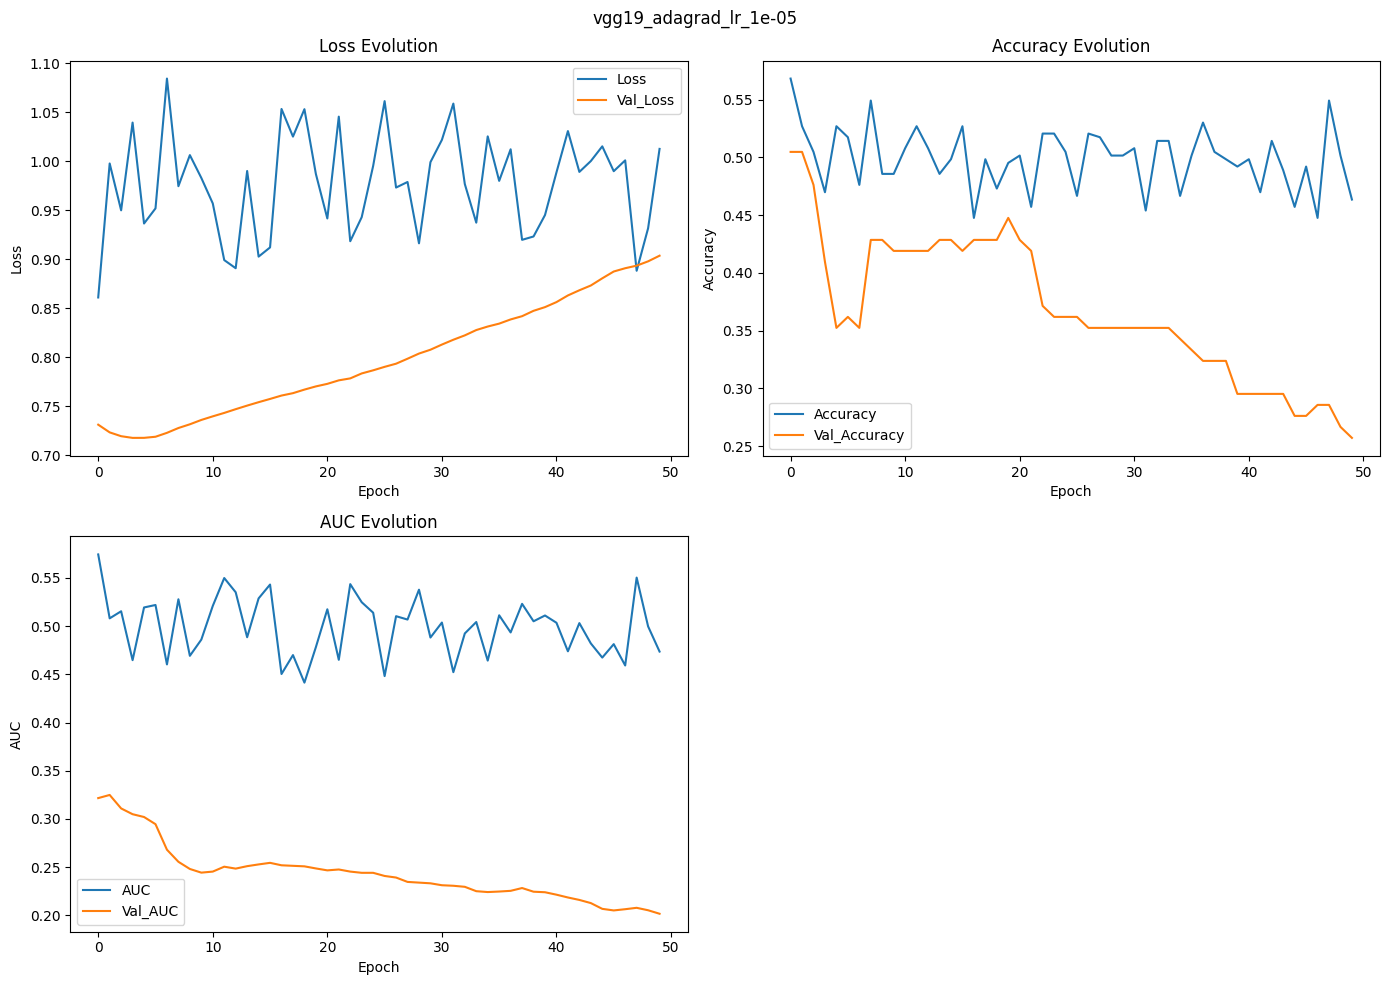

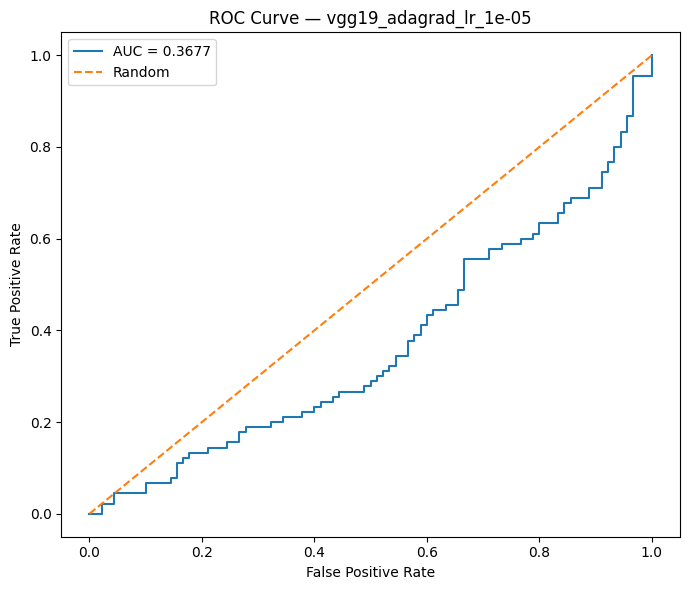

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,41,49
Actual With Disease,61,29


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adagrad,0.00001,0.388889,0.371795,0.322222,0.455556,0.345238,0.367654,41,49,61,29,outputs_vgg19\plots\vgg19_adagrad_lr_1e-05_his...,outputs_vgg19\plots\vgg19_adagrad_lr_1e-05_roc...,outputs_vgg19\reports\vgg19_adagrad_lr_1e-05_c...,outputs_vgg19\confusion_matrices\vgg19_adagrad...


,precision,recall,f1-score,support
Without Disease,0.401961,0.455556,0.427083,90.000000
With Disease,0.371795,0.322222,0.345238,90.000000
accuracy,0.388889,0.388889,0.388889,0.388889
macro avg,0.386878,0.388889,0.386161,180.000000
weighted avg,0.386878,0.388889,0.386161,180.000000



Running: vgg19_adagrad_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 47s 5s/step - accuracy: 0.4667 - auc: 0.4694 - loss: 1.0365 - precision: 0.4667 - recall: 0.4430 - val_accuracy: 0.4952 - val_auc: 0.6841 - val_loss: 0.7530 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.5492 - auc: 0.5556 - loss: 0.8997 - precision: 0.5541 - recall: 0.5190 - val_accuracy: 0.4952 - val_auc: 0.6834 - val_loss: 0.7352 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.5270 - auc: 0.4897 - loss: 1.0138 - precision: 0.5287 - recall: 0.5253 - val_accuracy: 0.4952 - val_auc: 0.6769 - val_loss: 0.7206 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.5238 - auc: 0.5306 - loss: 0.9263 - precision: 0.5256 - recall: 0.5190 - val_accuracy: 0.4952 - val_auc: 0.6825 - val_loss: 0.7076 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 5

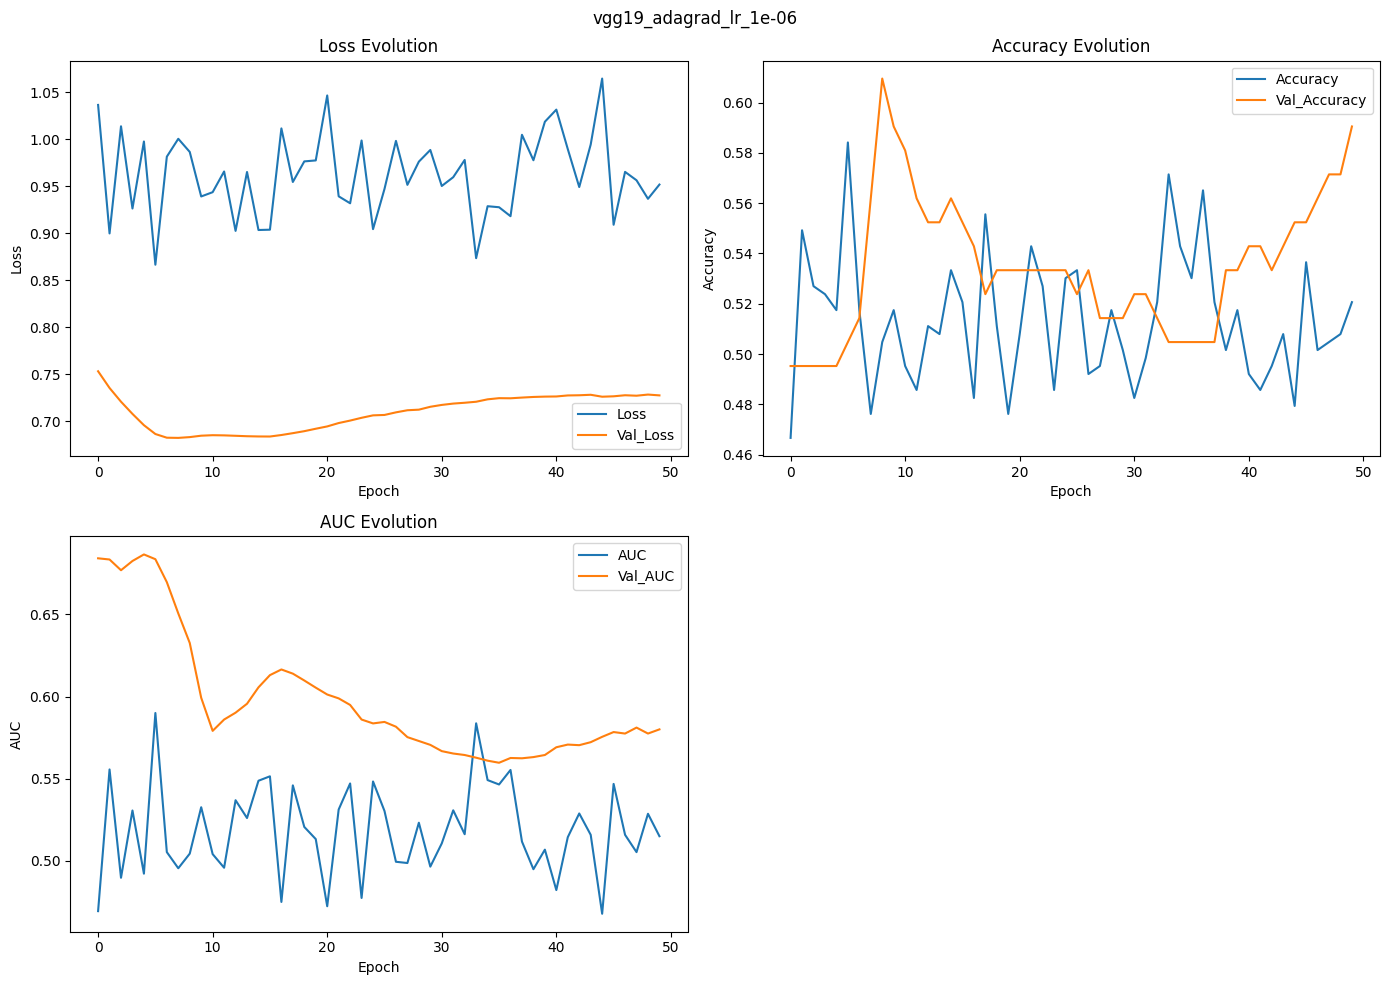

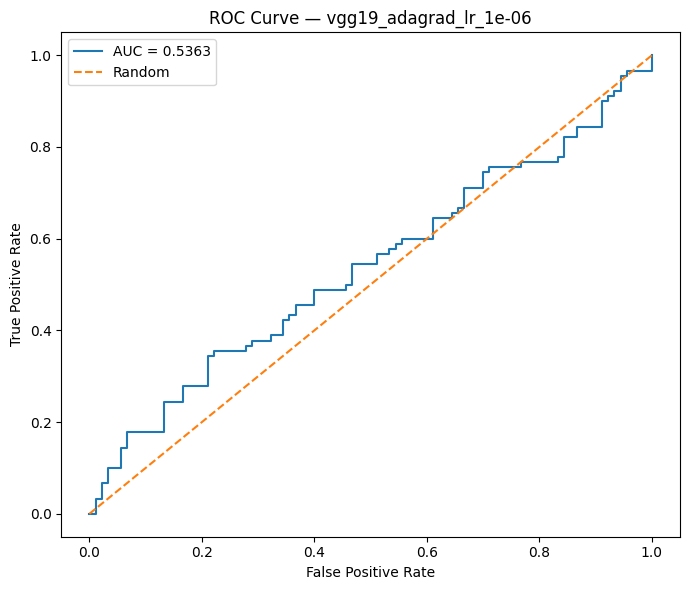

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,11,79
Actual With Disease,14,76


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adagrad,0.000001,0.483333,0.490323,0.844444,0.122222,0.620408,0.536296,11,79,14,76,outputs_vgg19\plots\vgg19_adagrad_lr_1e-06_his...,outputs_vgg19\plots\vgg19_adagrad_lr_1e-06_roc...,outputs_vgg19\reports\vgg19_adagrad_lr_1e-06_c...,outputs_vgg19\confusion_matrices\vgg19_adagrad...


,precision,recall,f1-score,support
Without Disease,0.440000,0.122222,0.191304,90.000000
With Disease,0.490323,0.844444,0.620408,90.000000
accuracy,0.483333,0.483333,0.483333,0.483333
macro avg,0.465161,0.483333,0.405856,180.000000
weighted avg,0.465161,0.483333,0.405856,180.000000



Running: vgg19_adamax_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.4857 - auc: 0.5025 - loss: 0.9781 - precision: 0.4873 - recall: 0.4873 - val_accuracy: 0.5048 - val_auc: 0.6156 - val_loss: 0.6967 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4857 - auc: 0.4824 - loss: 1.0045 - precision: 0.4875 - recall: 0.4937 - val_accuracy: 0.5048 - val_auc: 0.6352 - val_loss: 0.6928 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4762 - auc: 0.4857 - loss: 0.9943 - precision: 0.4785 - recall: 0.4937 - val_accuracy: 0.5048 - val_auc: 0.6319 - val_loss: 0.6897 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.5397 - auc: 0.5628 - loss: 0.8940 - precision: 0.5409 - recall: 0.5443 - val_accuracy: 0.5333 - val_auc: 0.6366 - val_loss: 0.6864 - val_precision: 0.8000 - va

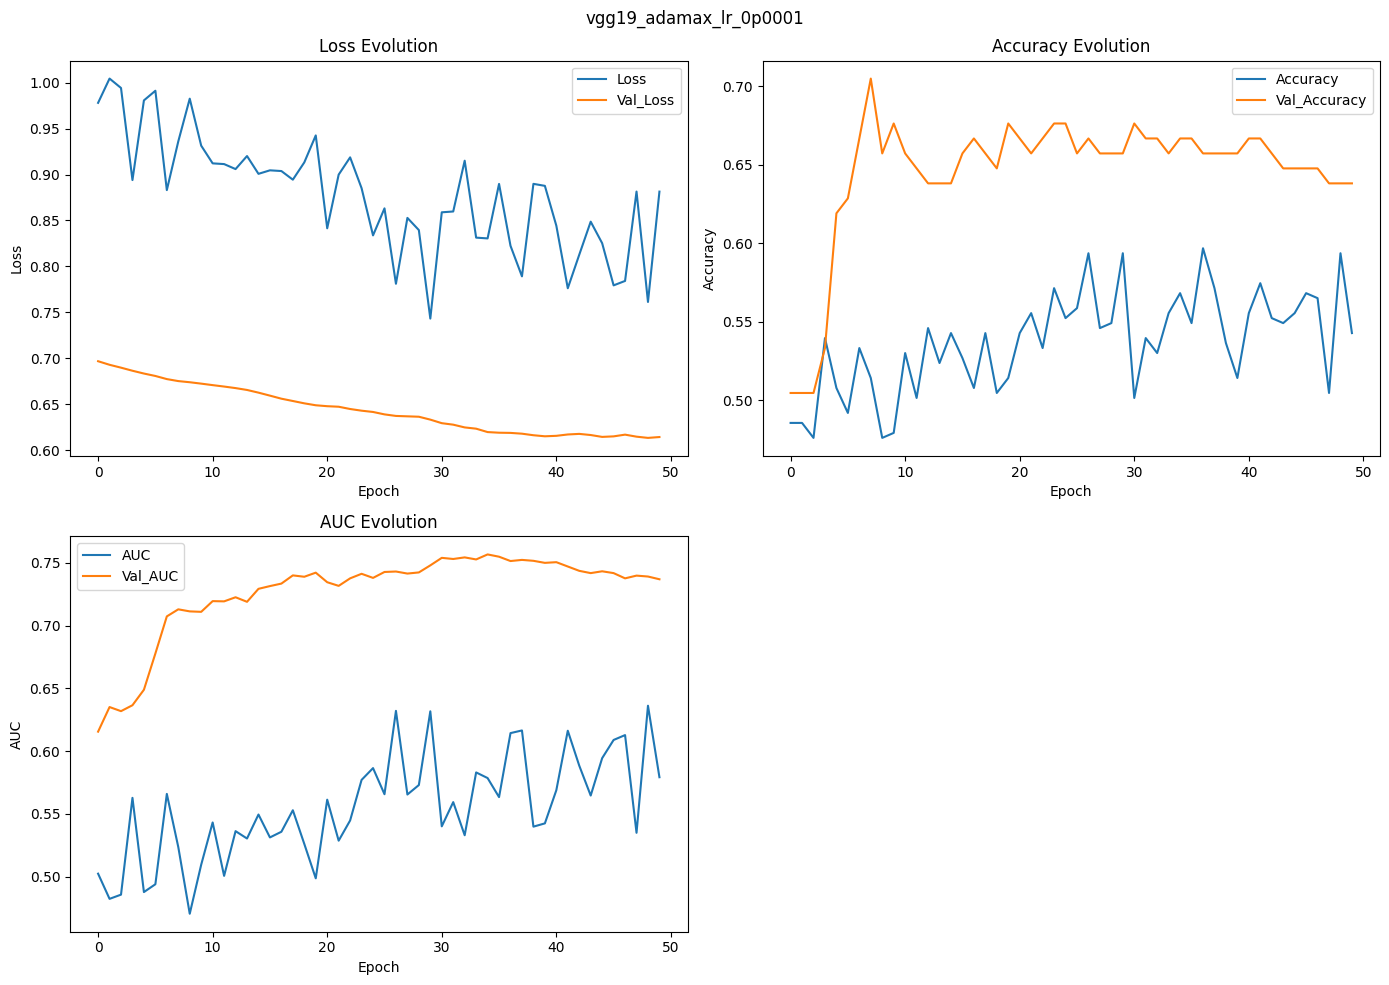

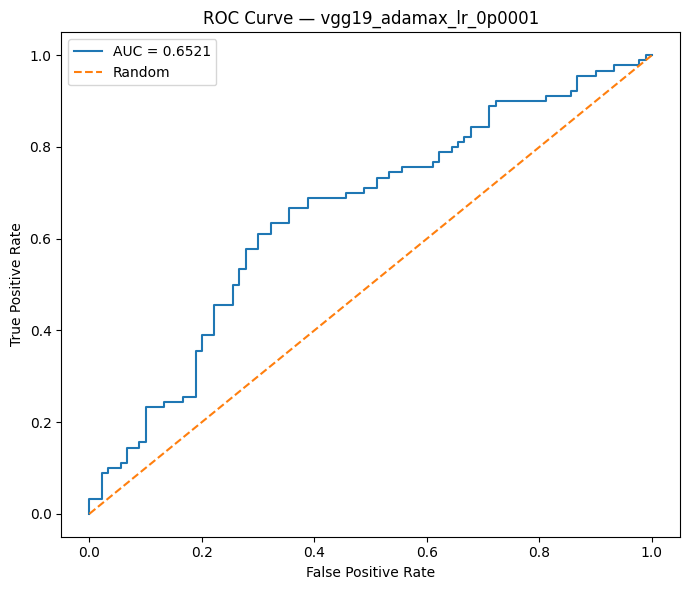

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,63,27
Actual With Disease,35,55


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adamax,0.0001,0.655556,0.670732,0.611111,0.7,0.639535,0.652099,63,27,35,55,outputs_vgg19\plots\vgg19_adamax_lr_0p0001_his...,outputs_vgg19\plots\vgg19_adamax_lr_0p0001_roc...,outputs_vgg19\reports\vgg19_adamax_lr_0p0001_c...,outputs_vgg19\confusion_matrices\vgg19_adamax_...


,precision,recall,f1-score,support
Without Disease,0.642857,0.700000,0.670213,90.000000
With Disease,0.670732,0.611111,0.639535,90.000000
accuracy,0.655556,0.655556,0.655556,0.655556
macro avg,0.656794,0.655556,0.654874,180.000000
weighted avg,0.656794,0.655556,0.654874,180.000000



Running: vgg19_adamax_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 79s 8s/step - accuracy: 0.4889 - auc: 0.4962 - loss: 1.0392 - precision: 0.4901 - recall: 0.4684 - val_accuracy: 0.4762 - val_auc: 0.5042 - val_loss: 0.6927 - val_precision: 0.4835 - val_recall: 0.8462
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 67s 7s/step - accuracy: 0.4825 - auc: 0.4952 - loss: 1.0259 - precision: 0.4845 - recall: 0.4937 - val_accuracy: 0.4381 - val_auc: 0.4672 - val_loss: 0.6949 - val_precision: 0.4521 - val_recall: 0.6346
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 70s 7s/step - accuracy: 0.5143 - auc: 0.5616 - loss: 0.8915 - precision: 0.5159 - recall: 0.5127 - val_accuracy: 0.3810 - val_auc: 0.4394 - val_loss: 0.6988 - val_precision: 0.4000 - val_recall: 0.5000
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 69s 7s/step - accuracy: 0.5397 - auc: 0.5500 - loss: 0.9374 - precision: 0.5404 - recall: 0.5506 - val_accuracy: 0.4000 - val_auc: 0.4120 - val_loss: 0.7037 - val_precision: 0.4225 - val_recall: 0.5769
Epoch 5/

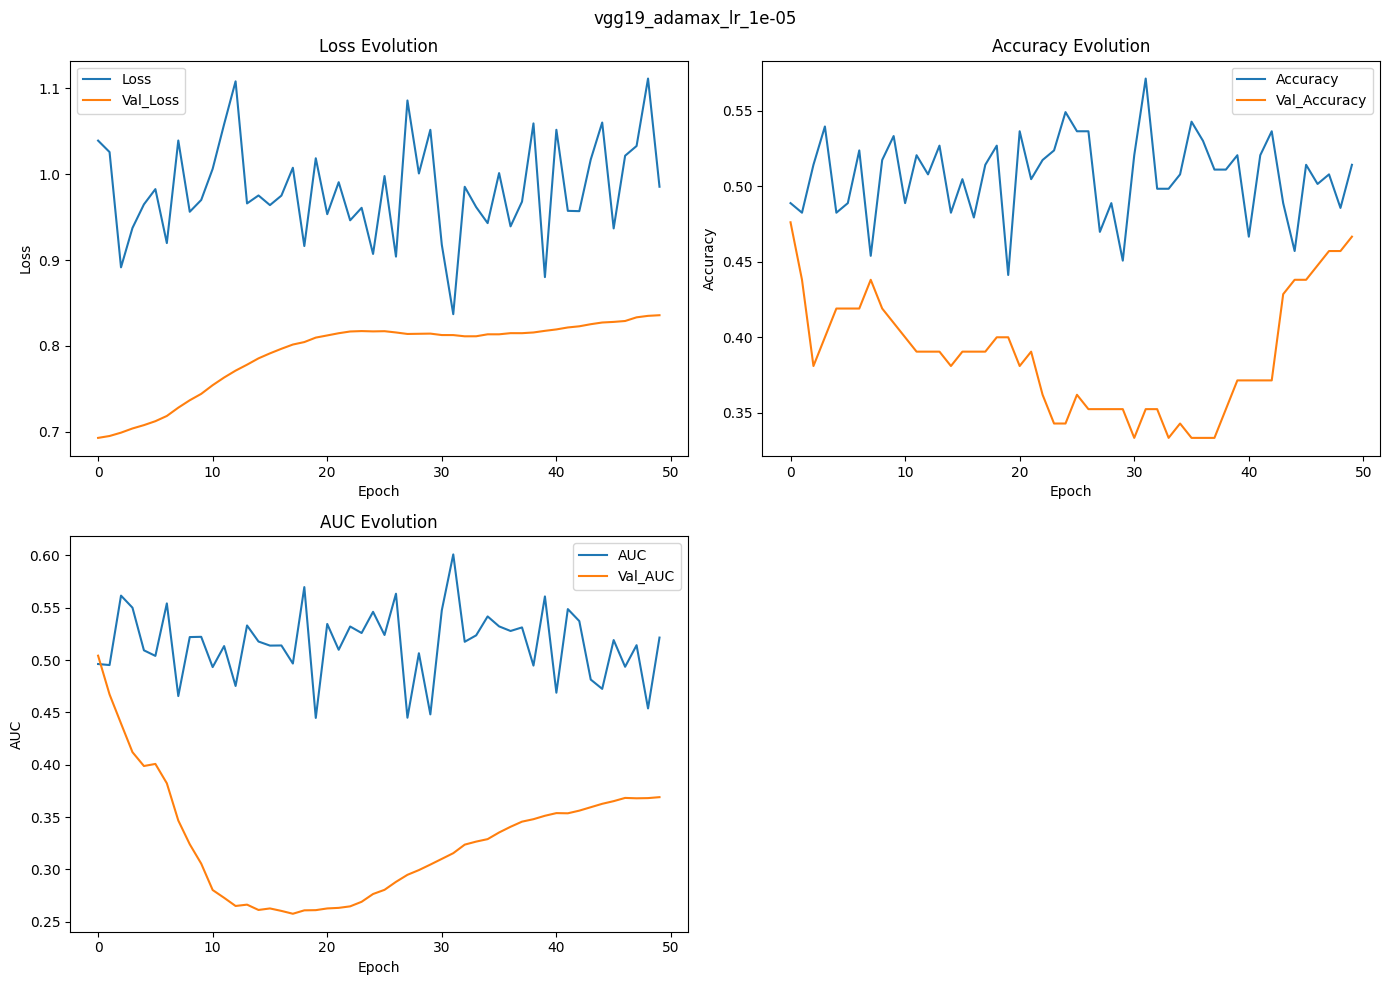

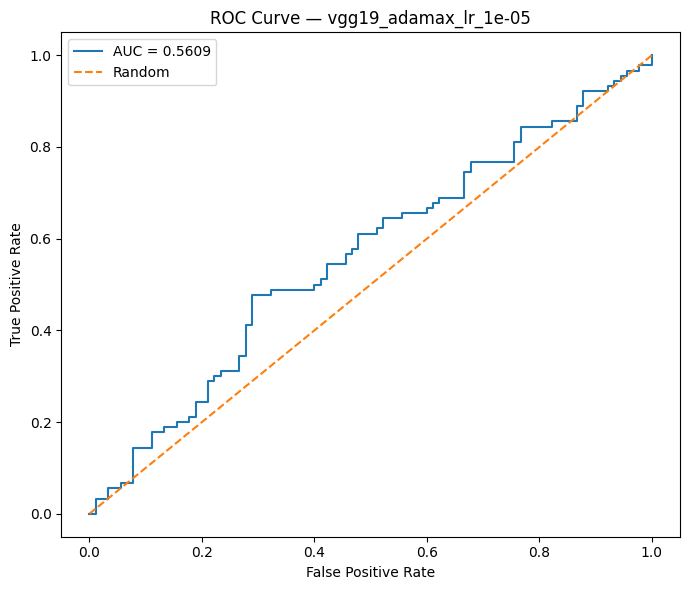

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,30,60
Actual With Disease,28,62


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adamax,0.00001,0.511111,0.508197,0.688889,0.333333,0.584906,0.560864,30,60,28,62,outputs_vgg19\plots\vgg19_adamax_lr_1e-05_hist...,outputs_vgg19\plots\vgg19_adamax_lr_1e-05_roc.png,outputs_vgg19\reports\vgg19_adamax_lr_1e-05_cl...,outputs_vgg19\confusion_matrices\vgg19_adamax_...


,precision,recall,f1-score,support
Without Disease,0.517241,0.333333,0.405405,90.000000
With Disease,0.508197,0.688889,0.584906,90.000000
accuracy,0.511111,0.511111,0.511111,0.511111
macro avg,0.512719,0.511111,0.495156,180.000000
weighted avg,0.512719,0.511111,0.495156,180.000000



Running: vgg19_adamax_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 81s 8s/step - accuracy: 0.4921 - auc: 0.5071 - loss: 0.9056 - precision: 0.4937 - recall: 0.4937 - val_accuracy: 0.4190 - val_auc: 0.3884 - val_loss: 0.7013 - val_precision: 0.4516 - val_recall: 0.8077
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 70s 7s/step - accuracy: 0.5302 - auc: 0.5150 - loss: 0.8749 - precision: 0.5316 - recall: 0.5316 - val_accuracy: 0.3905 - val_auc: 0.3082 - val_loss: 0.7047 - val_precision: 0.4318 - val_recall: 0.7308
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 69s 7s/step - accuracy: 0.5175 - auc: 0.5217 - loss: 0.9059 - precision: 0.5197 - recall: 0.5000 - val_accuracy: 0.3524 - val_auc: 0.2707 - val_loss: 0.7071 - val_precision: 0.3919 - val_recall: 0.5577
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 71s 7s/step - accuracy: 0.5556 - auc: 0.5540 - loss: 0.8437 - precision: 0.5556 - recall: 0.5696 - val_accuracy: 0.3619 - val_auc: 0.2801 - val_loss: 0.7087 - val_precision: 0.3729 - val_recall: 0.4231
Epoch 5/

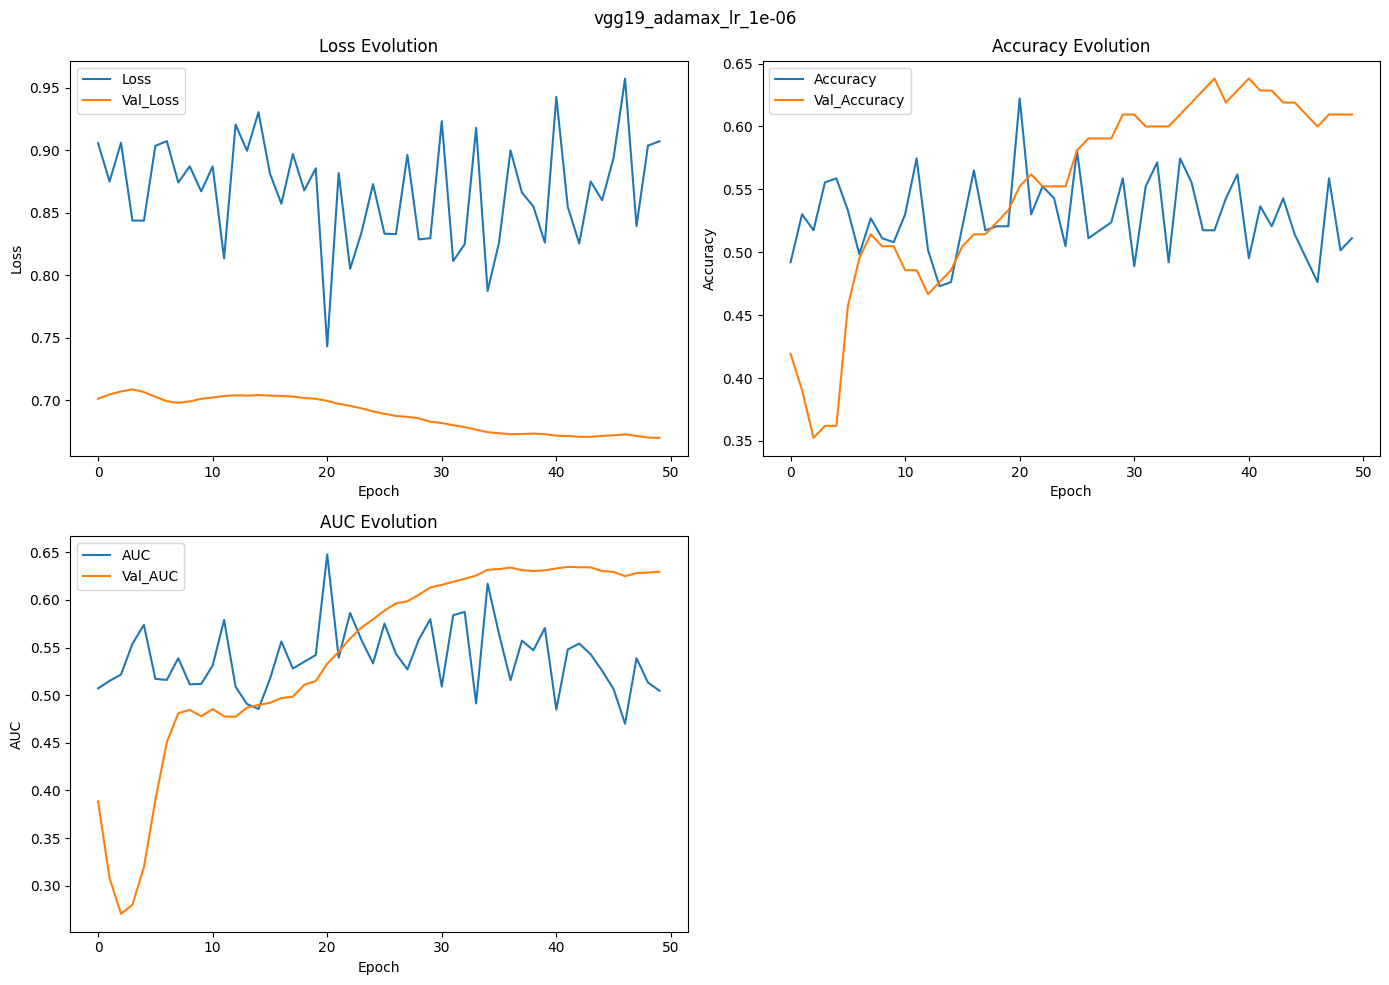

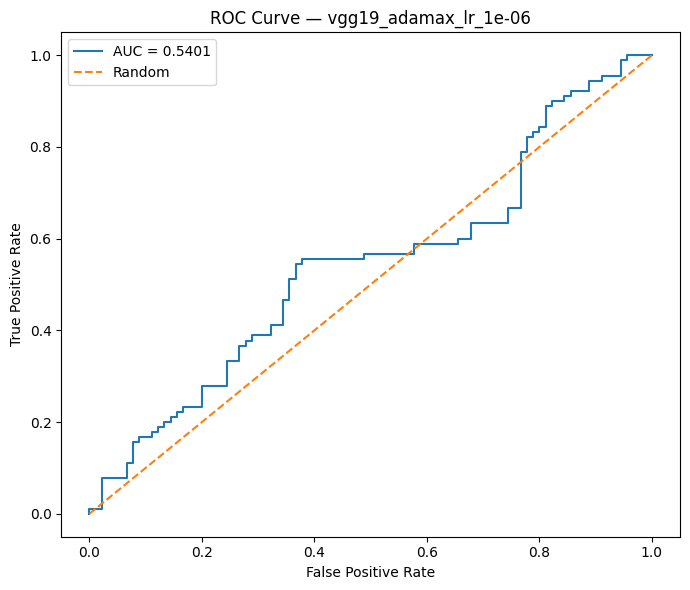

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,33,57
Actual With Disease,37,53


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adamax,0.000001,0.477778,0.481818,0.588889,0.366667,0.53,0.540123,33,57,37,53,outputs_vgg19\plots\vgg19_adamax_lr_1e-06_hist...,outputs_vgg19\plots\vgg19_adamax_lr_1e-06_roc.png,outputs_vgg19\reports\vgg19_adamax_lr_1e-06_cl...,outputs_vgg19\confusion_matrices\vgg19_adamax_...


,precision,recall,f1-score,support
Without Disease,0.471429,0.366667,0.412500,90.000000
With Disease,0.481818,0.588889,0.530000,90.000000
accuracy,0.477778,0.477778,0.477778,0.477778
macro avg,0.476623,0.477778,0.471250,180.000000
weighted avg,0.476623,0.477778,0.471250,180.000000



Running: vgg19_adadelta_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 77s 7s/step - accuracy: 0.5048 - auc: 0.5176 - loss: 0.9082 - precision: 0.5064 - recall: 0.5000 - val_accuracy: 0.5524 - val_auc: 0.5183 - val_loss: 0.6927 - val_precision: 1.0000 - val_recall: 0.0962
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.4984 - auc: 0.4985 - loss: 0.9255 - precision: 0.5000 - recall: 0.5127 - val_accuracy: 0.5429 - val_auc: 0.5116 - val_loss: 0.6940 - val_precision: 1.0000 - val_recall: 0.0769
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.5333 - auc: 0.5337 - loss: 0.8985 - precision: 0.5374 - recall: 0.5000 - val_accuracy: 0.5524 - val_auc: 0.4770 - val_loss: 0.6971 - val_precision: 1.0000 - val_recall: 0.0962
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 6s/step - accuracy: 0.5143 - auc: 0.4910 - loss: 0.9087 - precision: 0.5150 - recall: 0.5443 - val_accuracy: 0.5333 - val_auc: 0.4586 - val_loss: 0.6999 - val_precision: 1.0000 - val_recall: 0.0577
Epoch

In [ ]:
results = []

def get_run_name(model_name, optimizer_name, lr):
    return f"{model_name}_{optimizer_name}_lr_{lr:g}".replace(".", "p")


def run_outputs_exist(model_name, optimizer_name, lr):
    run_name = get_run_name(model_name, optimizer_name, lr)

    expected_files = [
        PLOTS_DIR / f"{run_name}_history.png",
        PLOTS_DIR / f"{run_name}_roc.png",
        REPORTS_DIR / f"{run_name}_classification_report.csv",
        CONFUSION_DIR / f"{run_name}_confusion_matrix.csv",
    ]

    return all(file.exists() for file in expected_files)


for model_name in MODELS_TO_RUN:
    for optimizer_name in OPTIMIZERS:
        for lr in LEARNING_RATES:
            if run_outputs_exist(model_name, optimizer_name, lr):
                print(f"Skipping completed run: {get_run_name(model_name, optimizer_name, lr)}")
                continue

            result = run_experiment(model_name, optimizer_name, lr)
            results.append(result)

            partial_results_df = pd.DataFrame(results)
            partial_results_df.to_csv(OUTPUT_DIR / "partial_results_summary.csv", index=False)

results_df = pd.DataFrame(results)

if not results_df.empty:
    results_df.to_csv(OUTPUT_DIR / "new_results_summary.csv", index=False)
    display(results_df)
else:
    print("No new runs were performed. All expected output files already exist.")

## Run VGG19 Experiments

This runs 18 simulations: 1 active model × 6 optimizers × 3 learning rates.

For the full 72 simulations, enable the other three model names in `MODELS_TO_RUN` above.



Running: vgg19_adam_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.5175 - auc: 0.5233 - loss: 0.9096 - precision: 0.5183 - recall: 0.5380 - val_accuracy: 0.4952 - val_auc: 0.5221 - val_loss: 0.7164 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.4540 - auc: 0.4595 - loss: 0.9796 - precision: 0.4545 - recall: 0.4430 - val_accuracy: 0.4857 - val_auc: 0.5408 - val_loss: 0.6955 - val_precision: 0.4904 - val_recall: 0.9808
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.5206 - auc: 0.5259 - loss: 0.9357 - precision: 0.5217 - recall: 0.5316 - val_accuracy: 0.5238 - val_auc: 0.5325 - val_loss: 0.6911 - val_precision: 0.5227 - val_recall: 0.4423
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.5206 - auc: 0.5088 - loss: 0.9385 - precision: 0.5238 - recall: 0.4873 - val_accuracy: 0.5429 - val_auc: 0.5405 - val_loss: 0.6933 - val_precision: 0.8333 - val_recall: 0.0962
Epoch 5/5

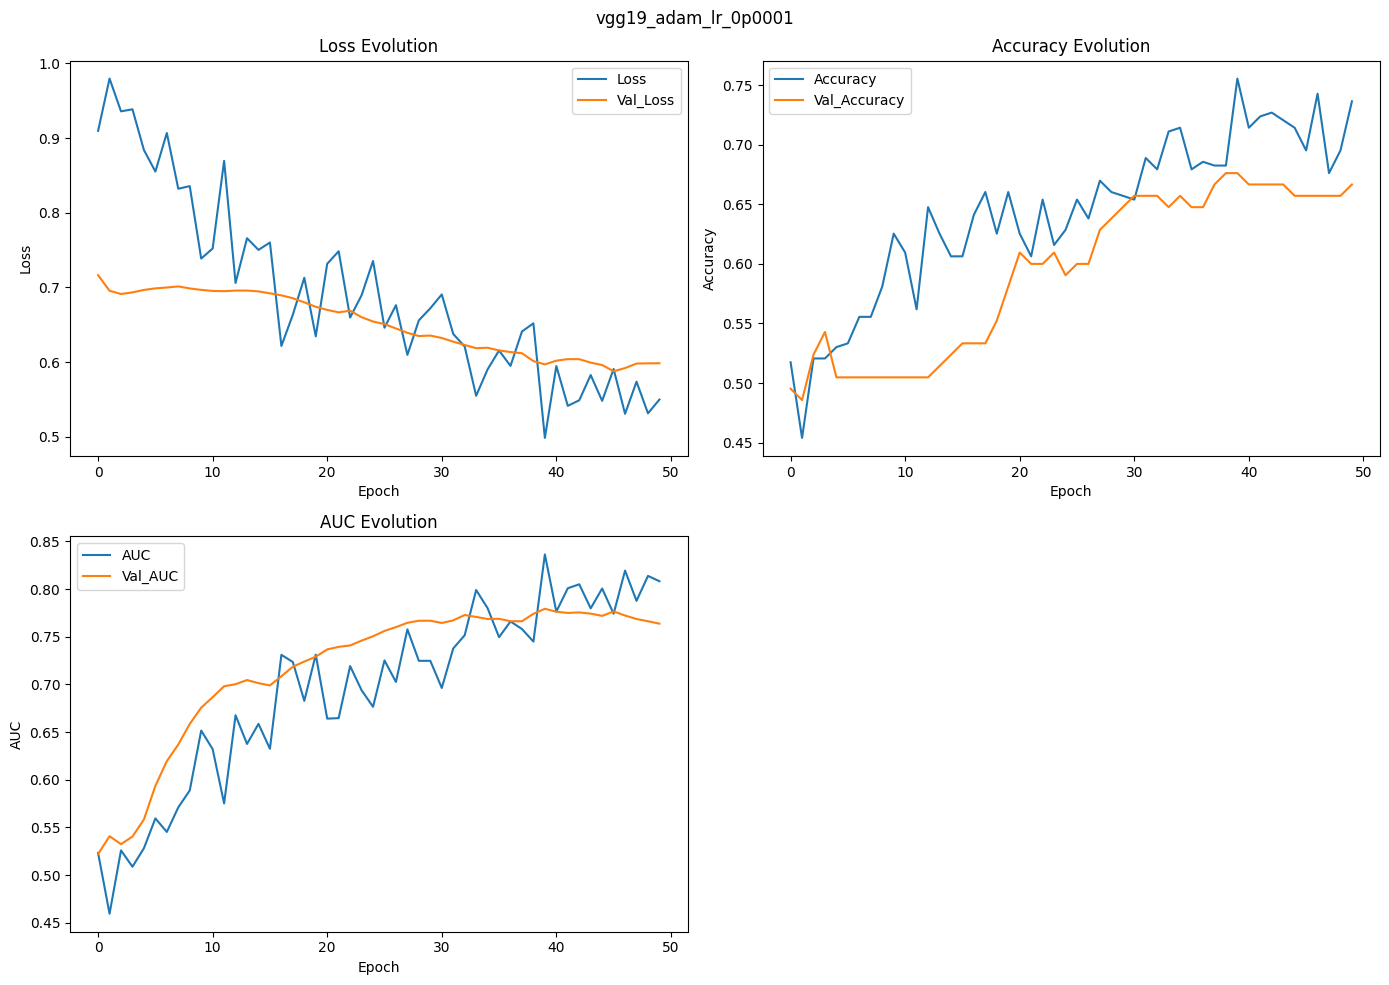

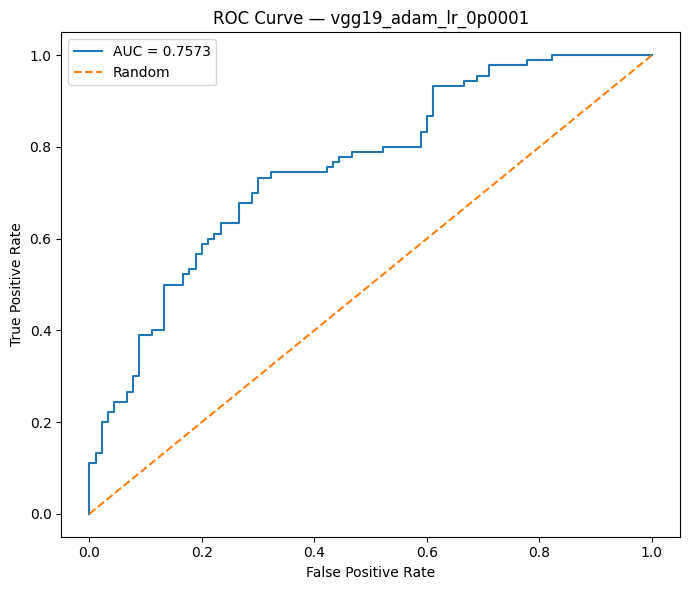

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,28,62
Actual With Disease,5,85


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adam,0.0001,0.627778,0.578231,0.944444,0.311111,0.7173,0.757284,28,62,5,85,outputs_vgg19\plots\vgg19_adam_lr_0p0001_histo...,outputs_vgg19\plots\vgg19_adam_lr_0p0001_roc.png,outputs_vgg19\reports\vgg19_adam_lr_0p0001_cla...,outputs_vgg19\confusion_matrices\vgg19_adam_lr...


,precision,recall,f1-score,support
Without Disease,0.848485,0.311111,0.455285,90.000000
With Disease,0.578231,0.944444,0.717300,90.000000
accuracy,0.627778,0.627778,0.627778,0.627778
macro avg,0.713358,0.627778,0.586292,180.000000
weighted avg,0.713358,0.627778,0.586292,180.000000



Running: vgg19_adam_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.5651 - auc: 0.5751 - loss: 0.8602 - precision: 0.5644 - recall: 0.5823 - val_accuracy: 0.5048 - val_auc: 0.3260 - val_loss: 0.7312 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 50s 5s/step - accuracy: 0.5238 - auc: 0.5115 - loss: 0.9934 - precision: 0.5235 - recall: 0.5633 - val_accuracy: 0.5048 - val_auc: 0.3324 - val_loss: 0.7230 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.4984 - auc: 0.5196 - loss: 0.9447 - precision: 0.5000 - recall: 0.4620 - val_accuracy: 0.4762 - val_auc: 0.3228 - val_loss: 0.7187 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.4762 - auc: 0.4711 - loss: 1.0295 - precision: 0.4777 - recall: 0.4747 - val_accuracy: 0.4095 - val_auc: 0.3142 - val_loss: 0.7167 - val_precision: 0.2917 - val_r

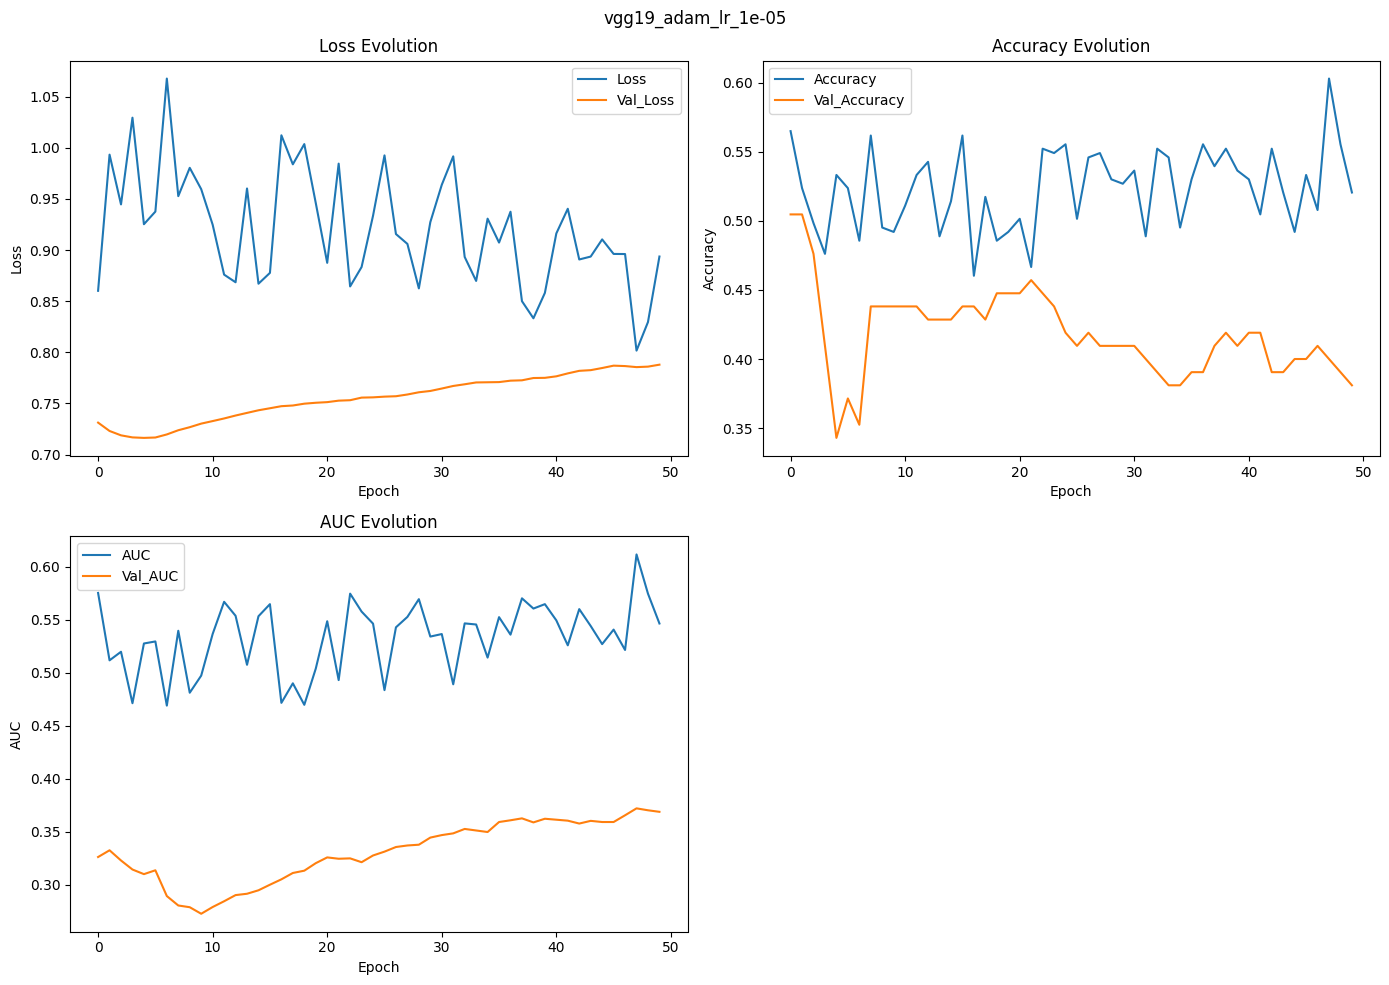

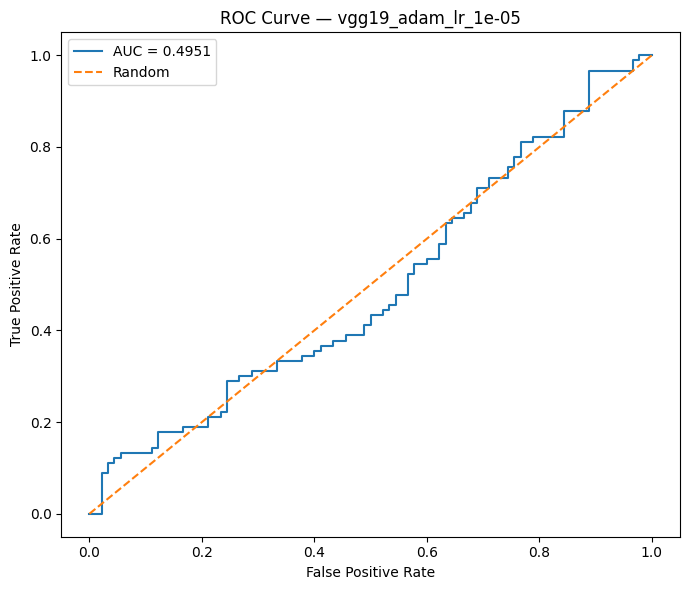

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,43,47
Actual With Disease,51,39


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adam,0.00001,0.455556,0.453488,0.433333,0.477778,0.443182,0.495062,43,47,51,39,outputs_vgg19\plots\vgg19_adam_lr_1e-05_histor...,outputs_vgg19\plots\vgg19_adam_lr_1e-05_roc.png,outputs_vgg19\reports\vgg19_adam_lr_1e-05_clas...,outputs_vgg19\confusion_matrices\vgg19_adam_lr...


,precision,recall,f1-score,support
Without Disease,0.457447,0.477778,0.467391,90.000000
With Disease,0.453488,0.433333,0.443182,90.000000
accuracy,0.455556,0.455556,0.455556,0.455556
macro avg,0.455468,0.455556,0.455287,180.000000
weighted avg,0.455468,0.455556,0.455287,180.000000



Running: vgg19_adam_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.4667 - auc: 0.4695 - loss: 1.0365 - precision: 0.4667 - recall: 0.4430 - val_accuracy: 0.4952 - val_auc: 0.6841 - val_loss: 0.7530 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 0.5492 - auc: 0.5559 - loss: 0.8994 - precision: 0.5541 - recall: 0.5190 - val_accuracy: 0.4952 - val_auc: 0.6834 - val_loss: 0.7352 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5270 - auc: 0.4902 - loss: 1.0132 - precision: 0.5287 - recall: 0.5253 - val_accuracy: 0.4952 - val_auc: 0.6756 - val_loss: 0.7206 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.5238 - auc: 0.5308 - loss: 0.9253 - precision: 0.5256 - recall: 0.5190 - val_accuracy: 0.4952 - val_auc: 0.6836 - val_loss: 0.7076 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 5/50

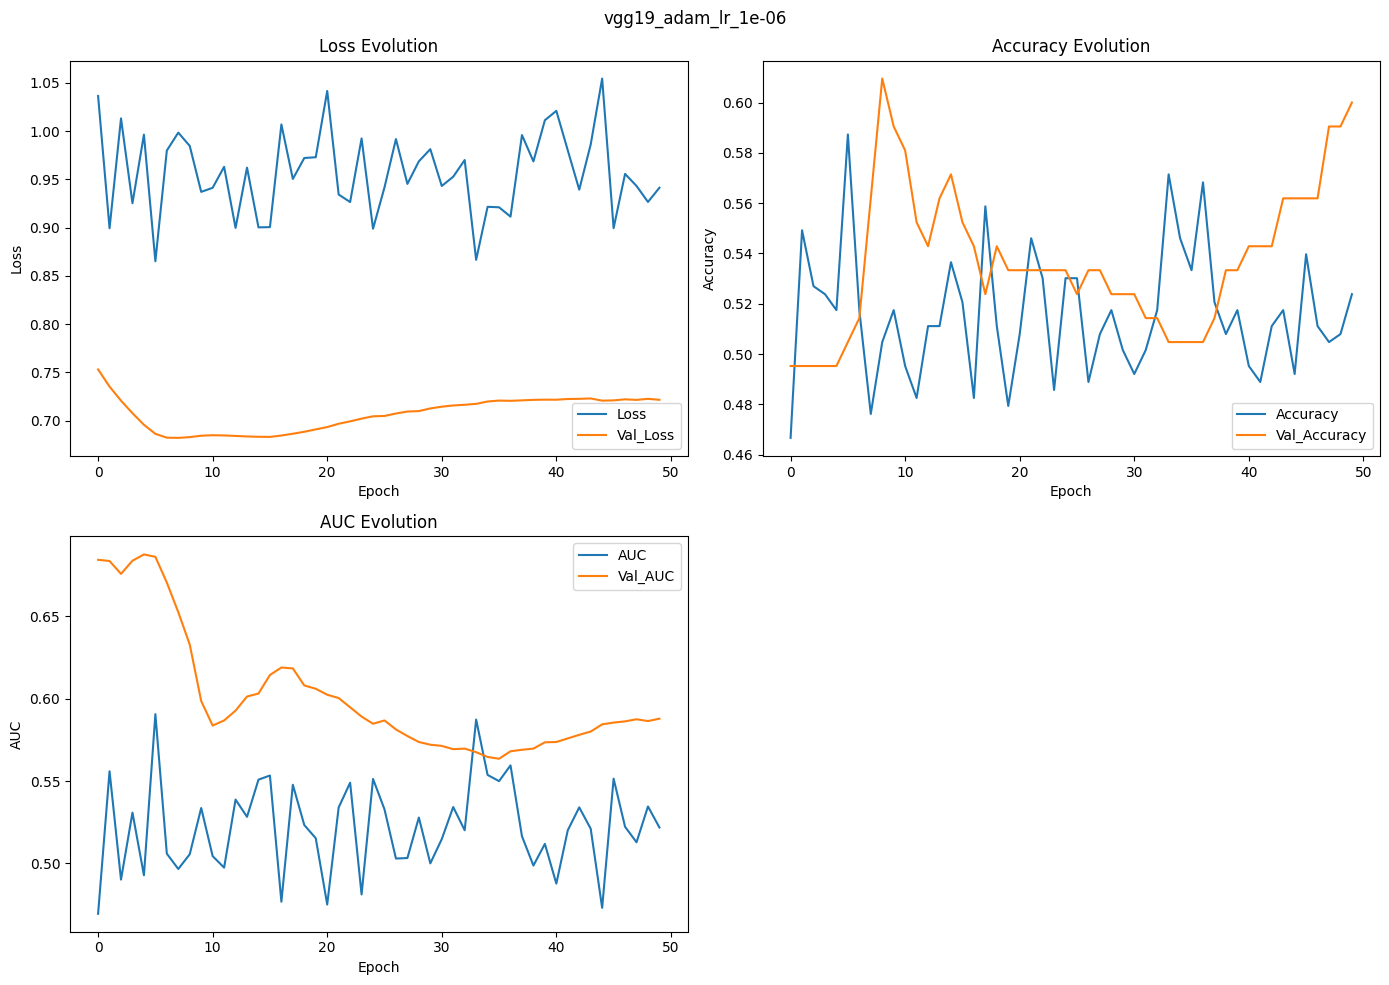

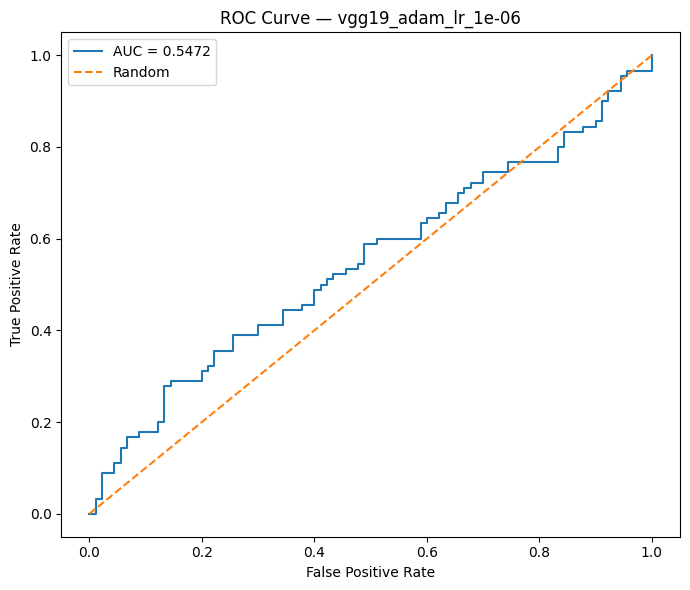

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,11,79
Actual With Disease,14,76


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,vgg19,adam,0.000001,0.483333,0.490323,0.844444,0.122222,0.620408,0.54716,11,79,14,76,outputs_vgg19\plots\vgg19_adam_lr_1e-06_histor...,outputs_vgg19\plots\vgg19_adam_lr_1e-06_roc.png,outputs_vgg19\reports\vgg19_adam_lr_1e-06_clas...,outputs_vgg19\confusion_matrices\vgg19_adam_lr...


,precision,recall,f1-score,support
Without Disease,0.440000,0.122222,0.191304,90.000000
With Disease,0.490323,0.844444,0.620408,90.000000
accuracy,0.483333,0.483333,0.483333,0.483333
macro avg,0.465161,0.483333,0.405856,180.000000
weighted avg,0.465161,0.483333,0.405856,180.000000



Running: vgg19_adagrad_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.4825 - auc: 0.5002 - loss: 0.9826 - precision: 0.4843 - recall: 0.4873 - val_accuracy: 0.5048 - val_auc: 0.6089 - val_loss: 0.6971 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 6s/step - accuracy: 0.4857 - auc: 0.4763 - loss: 1.0173 - precision: 0.4877 - recall: 0.5000 - val_accuracy: 0.5048 - val_auc: 0.6337 - val_loss: 0.6933 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.4698 - auc: 0.4724 - loss: 1.0209 - precision: 0.4724 - recall: 0.4873 - val_accuracy: 0.5048 - val_auc: 0.6284 - val_loss: 0.6907 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.5429 - auc: 0.5493 - loss: 0.9180 - precision: 0.5449 - recall: 0.5380 - val_accuracy: 0.5143 - val_auc: 0.6235 - val_loss: 0.6879 - val_precision: 0.6667 - v

In [ ]:
results = []

for model_name in MODELS_TO_RUN:
    for optimizer_name in OPTIMIZERS:
        for lr in LEARNING_RATES:
            result = run_experiment(model_name, optimizer_name, lr)
            results.append(result)

results_df = pd.DataFrame(results)
results_csv_path = OUTPUT_DIR / "vgg19_results_summary.csv"
results_df.to_csv(results_csv_path, index=False)

print(f"Saved summary results to: {results_csv_path}")
display(results_df)


## Best Run Summary


In [ ]:
if "results_df" in globals() and not results_df.empty:
    best_by_auc = results_df.sort_values("auc", ascending=False).head(1)
    best_by_accuracy = results_df.sort_values("accuracy", ascending=False).head(1)

    print("Best run by AUC:")
    display(best_by_auc)

    print("Best run by Accuracy:")
    display(best_by_accuracy)
